### News Data Pre-Processing

In [1]:
#Packages
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import collocations
from nltk.collocations import BigramCollocationFinder
from nltk.metrics import BigramAssocMeasures
from sklearn.feature_extraction.text import TfidfVectorizer
import string
import time
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import numpy as np
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
#Nltk functions
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)

True

In [3]:
#Data
dataset_A = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\News_Dataset A.csv")
dataset_B = pd.read_csv(r"C:\Users\USER\PycharmProjects\ThesisProject\Data\News\News_Dataset B.csv")

In [4]:
dataset_A.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366
2,2023-12-12,Bigbear.Ai (BBAI) Extends Deal With U.S. Army ...,ADSK,BigBear.ai BBAI is keeping no stone unturned t...,It also partnered with Autodesk ADSK to develo...,"Click to get this free report Amazon.com, Inc....",2023,4136


In [5]:
dataset_B.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,relevance_score,Relevance_Tier,Month
0,2019-01-02,The Fire Within Netflix Stock Still Burns Desp...,CMCSA,"InvestorPlace - Stock Market News, Stock Advic...",The result is many analysts are now piling int...,The result is many analysts are now piling int...,2019,5001,4,Low Impact (2-4),1
1,2019-01-02,Don’t Let the Class-Action Suit Dissuade You f...,INTC,"InvestorPlace - Stock Market News, Stock Advic...",7 Stocks to Sell In January Another top compet...,7 Stocks to Sell In January Another top compet...,2019,6003,4,Low Impact (2-4),1
2,2019-01-02,"Top Research Reports for Facebook, Wells Fargo...",INTC,"Wednesday, January 2, 2018\nThe Zacks Research...",Other noteworthy reports we are featuring toda...,Click to get this free report Wells Fargo & Co...,2019,8537,14,High Impact (10+),1


In [6]:
#Initiating Lemmatizer
lemmatizer = WordNetLemmatizer()

In [7]:
#Stopword and Rescue strategy
def get_final_stops():
    stop_words = set(stopwords.words('english'))
    
    #Rescue lIST : Critical for Financial Sentiment
    #Will be removed from the stopword list so they are NOT deleted.
    rescue_list = {
        'not', 'no', 'never', 'none', 'neither', 'nor', 'but', 
        'up', 'down', 'above', 'below', 'higher', 'lower', 'high', 'low',
        'off', 'under', 'over', 'against', 'only',
        'growth', 'gain', 'loss', 
    }
    
    for word in rescue_list:
        stop_words.discard(word)
    
    #Adding noise artifacts and single letters to the final ban list
    #'wa' is added to catch the common WordNet lemmatization error of 'was'
    noise_artifacts = {'would', 'could', 'also', 'wa', 'ha', 'get', 'take'}
    alphabet_noise = set(string.ascii_lowercase) - {'a', 'i'}
    
    final_stops = stop_words.union(noise_artifacts).union(alphabet_noise)
    return final_stops

FINAL_STOPS = get_final_stops()

In [8]:
#Pre-compiled Regex
#USA Pattern: Normalizes all variants into 'usa'
USA_PATTERN = re.compile(r'\b(u\.s\.a\.|u\.s\.a|usa|u\.s\.|u\.s|u\s+s)\b', re.IGNORECASE)

#Abbreviation Collapser: i.e 'i.m.f.' -> 'imf'
ABV_PROTECT_RE = re.compile(r'(?<=[a-z])\.(?=[a-z])')

#Noise Cleaner: Keeps letters and numbers
CLEAN_ALPHA_NUM_RE = re.compile(r'[^a-z0-9\s]')

#Digit Masking: Turns specific numbers into a generic 'num' feature
DIGIT_MASK_RE = re.compile(r'\b\d+(?:\.\d+)?(?:m|b|k|%)?\b')

In [9]:
#Master Pre-procesing Function
def preprocess_fin_text(text):
    
    if not isinstance(text, str) or text.strip() == "":
        return ""

    #Case Folding
    text = text.lower()
    
    #USA Normalization
    text = USA_PATTERN.sub('placeholderusa', text)

    #Collapsing Abbreviations
    text = ABV_PROTECT_RE.sub('', text)

    #Metric Masking (Preserves context of magnitude without feature sparsity)
    # This turns '5.2%' or '100m' into 'num'
    text = DIGIT_MASK_RE.sub('num', text)

    #Removes Punctuation/Special Characters
    text = CLEAN_ALPHA_NUM_RE.sub(' ', text)

    #Whitespace Tokenization
    tokens = text.split()

    #Lemmatization and Final Stopword Filtering
    cleaned_tokens = []
    for w in tokens:
        w_lem = lemmatizer.lemmatize(w)
        
        if w_lem not in FINAL_STOPS:
            # Restore USA placeholder
            if w_lem == 'placeholderusa':
                cleaned_tokens.append('usa')
            else:
                cleaned_tokens.append(w_lem)

    return " ".join(cleaned_tokens)

In [10]:
#Validation 
test_samples = [
    "The U.S. economy did not grow by 5% in Q1.",
    "Revenue was up by 10.5M but margins fell below expectations.",
    "Discussion by u s officials regarding U.S.A. trade in the U.K."
]

print("Pipeline Validation")
for sample in test_samples:
    print(f"Raw: {sample}")
    print(f"Proc: {preprocess_fin_text(sample)}\n")

Pipeline Validation
Raw: The U.S. economy did not grow by 5% in Q1.
Proc: usa economy not grow num q1

Raw: Revenue was up by 10.5M but margins fell below expectations.
Proc: revenue up num but margin fell below expectation

Raw: Discussion by u s officials regarding U.S.A. trade in the U.K.
Proc: discussion usa official regarding usa trade uk



In [11]:
#Validation using Sample News from our dataset
sample_text = """ The market expects Paypal (PYPL) to deliver a year-over-year increase in earnings on higher revenues when it reports results for the quarter ended September 2023. This widely-known consensus outlook is important in assessing the company's earnings picture, but a powerful factor that might influence its near-term stock price is how the actual results compare to these estimates.
The stock might move higher if these key numbers top expectations in the upcoming earnings report, which is expected to be released on November 1. On the other hand, if they miss, the stock may move lower.
While management's discussion of business conditions on theearnings callwill mostly determine the sustainability
"""

In [12]:
print(f"RAW: {sample_text}")
print(f"PROC: {preprocess_fin_text(sample_text)}\n")

RAW:  The market expects Paypal (PYPL) to deliver a year-over-year increase in earnings on higher revenues when it reports results for the quarter ended September 2023. This widely-known consensus outlook is important in assessing the company's earnings picture, but a powerful factor that might influence its near-term stock price is how the actual results compare to these estimates.
The stock might move higher if these key numbers top expectations in the upcoming earnings report, which is expected to be released on November 1. On the other hand, if they miss, the stock may move lower.
While management's discussion of business conditions on theearnings callwill mostly determine the sustainability

PROC: market expects paypal pypl deliver year over year increase earnings higher revenue report result quarter ended september num widely known consensus outlook important assessing company earnings picture but powerful factor might influence near term stock price actual result compare estimat

In [13]:
#Applying to main datasets
#List of columns to process
cols_to_process = ['Article_title', 'Article', 'Lsa_summary', 'Textrank_summary']
new_cols = ['P_Article_title', 'P_Article', 'P_LSA', 'P_Textrank_']

In [14]:
#Timed Processing 
start = time.time()
dataset_A[new_cols] = dataset_A[cols_to_process].map(preprocess_fin_text)
dataset_B[new_cols] = dataset_B[cols_to_process].map(preprocess_fin_text)
end = time.time()
print(f"Total processing time: {end - start:.2f} seconds")

Total processing time: 894.38 seconds


In [15]:
dataset_A.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,P_Article_title,P_Article,P_LSA,P_Textrank_
0,2023-12-16,ADSK Quantitative Stock Analysis,ADSK,Below is Validea's guru fundamental report for...,Below is Validea's guru fundamental report for...,"Of the 22 guru strategies we follow, ADSK rate...",2023,2968,adsk quantitative stock analysis,below validea guru fundamental report autodesk...,below validea guru fundamental report autodesk...,num guru strategy follow adsk rate highest usi...
1,2023-12-16,Artificial Intelligence Adding New Depths to 3...,ADSK,3D scanners are used across a wide range of in...,Autodesk (ADSK) is a software company serving ...,Autodesk (ADSK) is a software company serving ...,2023,9366,artificial intelligence adding new depth 3d sc...,3d scanner used across wide range industry app...,autodesk adsk software company serving industr...,autodesk adsk software company serving industr...
2,2023-12-12,Bigbear.Ai (BBAI) Extends Deal With U.S. Army ...,ADSK,BigBear.ai BBAI is keeping no stone unturned t...,It also partnered with Autodesk ADSK to develo...,"Click to get this free report Amazon.com, Inc....",2023,4136,bigbearai bbai extends deal usa army gfim system,bigbearai bbai keeping no stone unturned expan...,partnered autodesk adsk develop smooth interfa...,click free report amazoncom inc amzn free stoc...


In [16]:
dataset_B.head(3)

,Date,Article_title,Stock_symbol,Article,Lsa_summary,Textrank_summary,Year,Article_Length,relevance_score,Relevance_Tier,Month,P_Article_title,P_Article,P_LSA,P_Textrank_
0,2019-01-02,The Fire Within Netflix Stock Still Burns Desp...,CMCSA,"InvestorPlace - Stock Market News, Stock Advic...",The result is many analysts are now piling int...,The result is many analysts are now piling int...,2019,5001,4,Low Impact (2-4),1,fire within netflix stock still burn despite p...,investorplace stock market news stock advice t...,result many analyst piling disney le risky pla...,result many analyst piling disney le risky pla...
1,2019-01-02,Don’t Let the Class-Action Suit Dissuade You f...,INTC,"InvestorPlace - Stock Market News, Stock Advic...",7 Stocks to Sell In January Another top compet...,7 Stocks to Sell In January Another top compet...,2019,6003,4,Low Impact (2-4),1,let class action suit dissuade nvidia stock,investorplace stock market news stock advice t...,num stock sell january another top competitor ...,num stock sell january another top competitor ...
2,2019-01-02,"Top Research Reports for Facebook, Wells Fargo...",INTC,"Wednesday, January 2, 2018\nThe Zacks Research...",Other noteworthy reports we are featuring toda...,Click to get this free report Wells Fargo & Co...,2019,8537,14,High Impact (10+),1,top research report facebook well fargo,wednesday january num num zacks research daily...,noteworthy report featuring today include inte...,click free report well fargo company wfc free ...


In [17]:
#Validating Random Articles in the Dataset
import random

sample_articles = random.sample(
    range(len(dataset_A)), 3
)

for article in sample_articles:

    print("\nRAW TEXT:\n")
    print(dataset_A.loc[article, 'Article'][:700])

    print("\nPROCESSED TEXT:\n")
    print(dataset_A.loc[article, 'P_Article'][:700])


RAW TEXT:

The NASDAQ 100 After Hours Indicator is down -2.14 to 7,576.7. The total After hours volume is currently 60,036,080 shares traded.
The following are the most active stocks for the after hours session :
Comcast Corporation ( CMCSA ) is +0.13 at $40.55, with 3,636,124 shares traded. Over the last four weeks they have had 4 up revisions for the earnings forecast, for the fiscal quarter ending Mar 2019. The consensus EPS forecast is $0.64. As reported by Zacks, the current mean recommendation for CMCSA is in the "buy range".
Annaly Capital Management Inc ( NLY ) is unchanged at $10.01, with 1,900,333 shares traded. As reported by Zacks, the current mean recommendation for NLY is in the "buy rang

PROCESSED TEXT:

nasdaq num hour indicator down num num num total hour volume currently num num num share traded following active stock hour session comcast corporation cmcsa num num num num num share traded over last four week num up revision earnings forecast fiscal quarter ending ma

In [18]:
#Checking if there are any missing values after pre-processing  #Dataset A
print(dataset_A.isnull().sum())

Date                0
Article_title       0
Stock_symbol        0
Article             0
Lsa_summary         0
Textrank_summary    0
Year                0
Article_Length      0
P_Article_title     0
P_Article           0
P_LSA               0
P_Textrank_         0
dtype: int64


In [19]:
print(dataset_B.isnull().sum())  #Dataset B

Date                0
Article_title       0
Stock_symbol        0
Article             0
Lsa_summary         0
Textrank_summary    0
Year                0
Article_Length      0
relevance_score     0
Relevance_Tier      0
Month               0
P_Article_title     0
P_Article           0
P_LSA               0
P_Textrank_         0
dtype: int64


In [20]:
#Vocabulary Compression Ratio (VCR) #Article Title Column
def calculate_vcr(df, raw_col, proc_col):
    #Getting set of unique tokens for Raw text
    raw_vocab = set(" ".join(df[raw_col].fillna('').astype(str)).split())
    #Getting set of unique tokens for Processed text
    proc_vocab = set(" ".join(df[proc_col].fillna('').astype(str)).split())
    
    vcr = 1 - (len(proc_vocab) / len(raw_vocab))
    
    print(f"Vocabulary Compression Analysis")
    print(f"Raw Unique Tokens:       {len(raw_vocab):,}")
    print(f"Processed Unique Tokens: {len(proc_vocab):,}")
    print(f"Vocabulary Reduction:    {vcr:.2%}")

    #return vcr

calculate_vcr(dataset_A, 'Article_title', 'P_Article_title')

Vocabulary Compression Analysis
Raw Unique Tokens:       44,381
Processed Unique Tokens: 18,005
Vocabulary Reduction:    59.43%


In [21]:
#Vocabulary Compression Ratio (VCR) #Article Column
calculate_vcr(dataset_A, 'Article', 'P_Article')

Vocabulary Compression Analysis
Raw Unique Tokens:       506,118
Processed Unique Tokens: 96,539
Vocabulary Reduction:    80.93%


The metrics proves that pre-processing has reduced the dimensionality problem by grouping synonyms and cleaning noise. This will make later modeling easier.

In [22]:
#Reviewing removed tokens - #Article Title Column
def audit_removed_tokens(df, raw_col, proc_col, top_n=50):
    #All words from raw and processed
    raw_words = " ".join(df[raw_col].fillna('').astype(str)).lower().split()
    proc_words = set(" ".join(df[proc_col].fillna('').astype(str)).split())
    
    #Finding words in raw that are NOT in processed
    removed_words = [word for word in raw_words if word not in proc_words]
    
    #Counting frequencies of the removed words
    removed_counts = Counter(removed_words).most_common(10)
    
    #Formatting for display
    audit_df = pd.DataFrame(removed_counts, columns=['Removed Token', 'Frequency'])
    return audit_df
    print(f"Removed Tokens Audit")
    print(audit_df)
    

audit_removed_tokens(dataset_A, 'Article_title', 'P_Article_title')

,Removed Token,Frequency
0,to,16796
1,for,10561
2,the,10451
3,in,9151
4,stocks,8778
5,on,6710
6,a,5928
7,is,5692
8,and,5593
9,of,5350


In [23]:
#Reviewing removed tokens - #Article Column
def audit_removed_tokens(df, raw_col, proc_col, top_n=50):
    #All words from raw and processed
    raw_words = " ".join(df[raw_col].fillna('').astype(str)).lower().split()
    proc_words = set(" ".join(df[proc_col].fillna('').astype(str)).split())
    
    #Finding words in raw that are NOT in processed
    removed_words = [word for word in raw_words if word not in proc_words]
    
    #Counting frequencies of the removed words
    removed_counts = Counter(removed_words).most_common(10)
    
    #Formatting for display
    audit_df = pd.DataFrame(removed_counts, columns=['Removed Token', 'Frequency'])
    return audit_df
    print(f"Removed Tokens Audit")
    print(audit_df)
    
audit_removed_tokens(dataset_A, 'Article', 'P_Article')

,Removed Token,Frequency
0,the,2264709
1,of,1148036
2,and,1109993
3,to,1055350
4,a,874974
5,in,781578
6,is,482072
7,for,457291
8,that,419589
9,on,359054


The audit validates that the most removed words are stopwords which demonstrates that the pre-processing pipeline was effective

In [24]:
#Sentiment Integrity (The "Rescue List" Check)
def validate_rescue_list(df, proc_col):
    rescue_words = ['up', 'down', 'high', 'low', 'above', 'below', 'gain', 'loss']
    all_text = " ".join(df[proc_col].dropna().astype(str)).lower().split()
    total_tokens = len(all_text)
    
    print(f"Rescue List Integrity Check")
    results = []
    for word in rescue_words:
        count = all_text.count(word)
        percentage = (count / total_tokens) * 100
        results.append({"Word": word, "Count": count, "Density (%)": round(percentage, 4)})
    
    validation_df = pd.DataFrame(results)
    print(validation_df)
    
    #Validation Rule: At least 'up' and 'down' should have non-zero counts
    if (validation_df.loc[validation_df['Word'].isin(['up', 'down']), 'Count'] > 0).all():
        print("\nDirectional markers preserved.")
    else:
        print("\nDirectional markers may have been stripped.")

validate_rescue_list(dataset_A, 'P_Article_title')

Rescue List Integrity Check
    Word  Count  Density (%)
0     up   1702       0.3533
1   down    917       0.1904
2   high   1126       0.2337
3    low    421       0.0874
4  above    204       0.0423
5  below    150       0.0311
6   gain   1171       0.2431
7   loss    277       0.0575

Directional markers preserved.


This validates that stopword removal didn't accidentally blind the model to market direction.

In [25]:
#The Comparative Health Audit Script
def validate_news_datasets(df_a, df_b, col_a='P_Article', col_b='P_Article'):
    """
    Compares the processed health of News Dataset A and Dataset B.
    """
    results = []
    datasets = [("Dataset A", df_a, col_a), ("Dataset B", df_b, col_b)]
    
    for name, df, col in datasets:
        #Calculate tokens
        raw_tokens = " ".join(df[col.replace('P_', '')].astype(str)).split() # Assumes raw col exists
        proc_tokens = " ".join(df[col].astype(str)).split()
        
        unique_raw = len(set(raw_tokens))
        unique_proc = len(set(proc_tokens))
        
        results.append({
            'Dataset': name,
            'Raw Unique Words': unique_raw,
            'Processed Unique (Features)': unique_proc,
            'Dimensionality Reduction': f"{round((1 - unique_proc/unique_raw)*100, 2)}%",
            'Top Signal Word': Counter(proc_tokens).most_common(1)[0][0]
        })
        
    return pd.DataFrame(results)

health_comparison = validate_news_datasets(dataset_A, dataset_B)
print(health_comparison)

     Dataset  Raw Unique Words  Processed Unique (Features)  \
0  Dataset A            506118                        96539   
1  Dataset B            421975                        83719   

  Dimensionality Reduction Top Signal Word  
0                   80.93%             num  
1                   80.16%             num  


There is not much differences in the two datasets, we shall use Dataset A as the primary dataset and only apply B for comparison purporses in future modeling and evaluation stages.

In [26]:
#Retention Metrics
def calculate_retention_metrics(df, raw_col, proc_col):
    #Counting tokens and handling potential non-string values
    raw_counts = df[raw_col].fillna('').astype(str).apply(lambda x: len(x.split()))
    proc_counts = df[proc_col].fillna('').astype(str).apply(lambda x: len(x.split()))
    
    #Calculating the Ratio: Raw / Processed
    #Adding tiny epsilon (1e-6) to avoid division by zero errors on empty rows
    retention_ratios = raw_counts / (proc_counts + 1e-6)
    
    #Aggregating Metrics
    avg_ratio = retention_ratios.mean()
    total_raw_tokens = raw_counts.sum()
    total_proc_tokens = proc_counts.sum()
    global_ratio = total_raw_tokens / total_proc_tokens
    
    print(f"Token Retention Analysis")
    print(f"Total Raw Tokens:       {total_raw_tokens:,}")
    print(f"Total Processed Tokens: {total_proc_tokens:,}")
    print(f"Global Retention Ratio: {global_ratio:.4f}")
    print(f"Average Row-wise Ratio: {avg_ratio:.4f}")
    
#Execution
calculate_retention_metrics(dataset_A, 'Article', 'P_Article')

Token Retention Analysis
Total Raw Tokens:       43,694,753
Total Processed Tokens: 27,401,929
Global Retention Ratio: 1.5946
Average Row-wise Ratio: 1.5144


By calculating the Token Retention Ratio, we are essentially measuring how much of the original content remains after we've stripped away the grammatical noise. The Result (1.6) indicates that for every 5 words a journalist wrote, a model only needs 3 words to understand the financial sentiment.

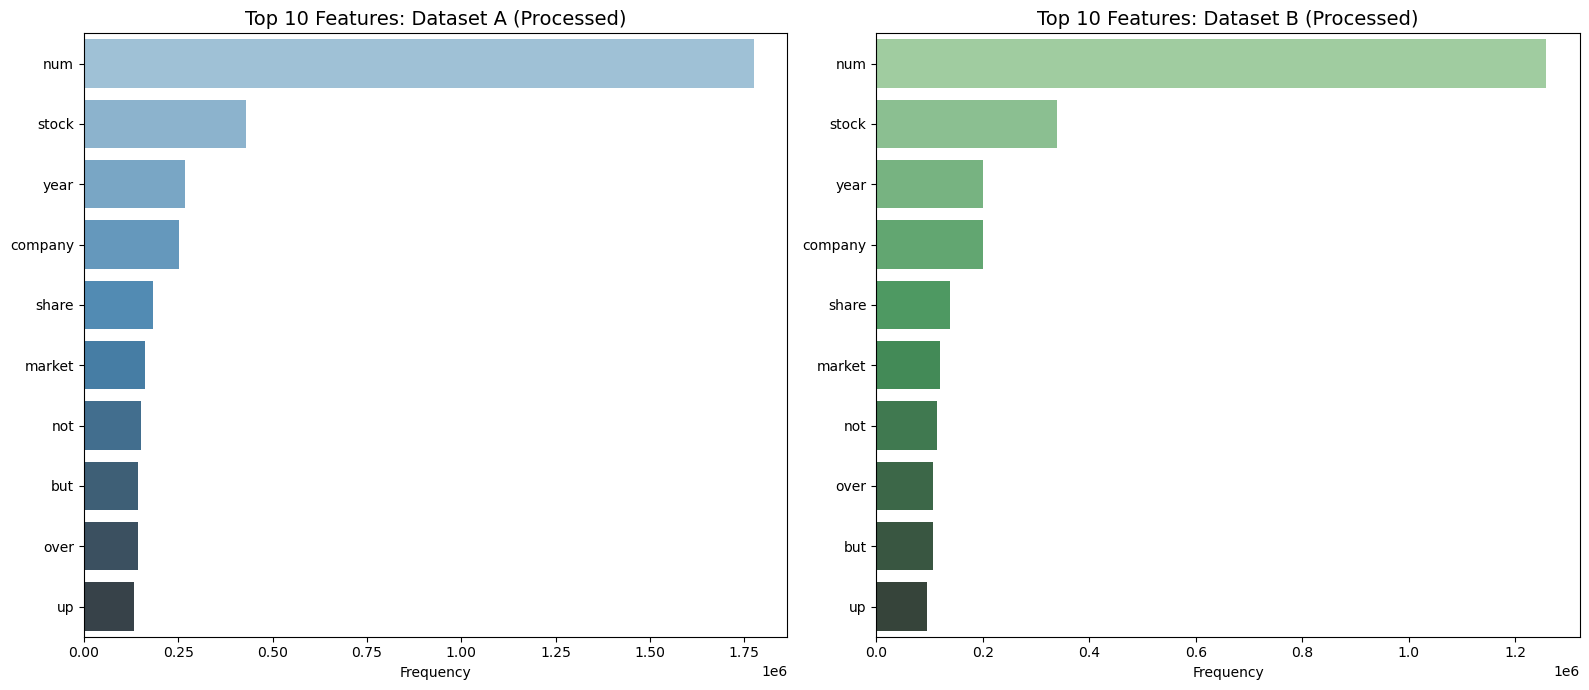

In [27]:
#Feature Distribution
def plot_news_feature_distribution(df_a, df_b, col_a='P_Article', col_b='P_Article'):
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    #Configuration for the two datasets
    plot_configs = [
        (df_a, col_a, "Dataset A (Processed)", "Blues_d"),
        (df_b, col_b, "Dataset B (Processed)", "Greens_d")
    ]
    
    for i, (df, col, name, color) in enumerate(plot_configs):
        clean_series = df[col].dropna().astype(str)
        
        #Flattening all rows into a single list of tokens
        #We use .str.cat to join them efficiently
        all_text = clean_series.str.cat(sep=' ')
        all_tokens = all_text.split()
        
        #Getting the Top 10 most frequent
        freq_dist = Counter(all_tokens).most_common(10)
        
        #Converting to a temporary DataFrame for Seaborn
        temp_df = pd.DataFrame(freq_dist, columns=['Feature', 'Frequency'])
        
        #Plot
        sns.barplot(
            data=temp_df,
            x='Frequency', 
            y='Feature', 
            ax=axes[i], 
            palette=color
        )
        axes[i].set_title(f"Top 10 Features: {name}", fontsize=14)
        axes[i].set_xlabel("Frequency")
        axes[i].set_ylabel("")

    plt.tight_layout()
    plt.savefig('Feature Distribution.png', dpi=300)
    plt.show()
    

plot_news_feature_distribution(dataset_A, dataset_B)

In [28]:
#N-Gram Co-occurrence Analysis
def get_top_ngrams(corpus, n=2, top_k=10):
    """Quickly checks top bigrams/trigrams without the full TF-IDF matrix."""
    words = " ".join(corpus).split()
    ngram_list = zip(*[words[i:] for i in range(n)])
    return Counter(ngram_list).most_common(top_k)

print("Top News Bigrams:", get_top_ngrams(dataset_B['P_Article_title'], n=2))

Top News Bigrams: [(('num', 'num'), 4931), (('stock', 'buy'), 2542), (('num', 'stock'), 1137), (('goldman', 'sachs'), 1066), (('update', 'num'), 1055), (('sector', 'update'), 1042), (('exxon', 'mobil'), 749), (('wall', 'street'), 705), (('num', 'top'), 679), (('stock', 'num'), 648)]


The above validates that the N-grams are capturing meaningful financial phrases rather than random word pairings.

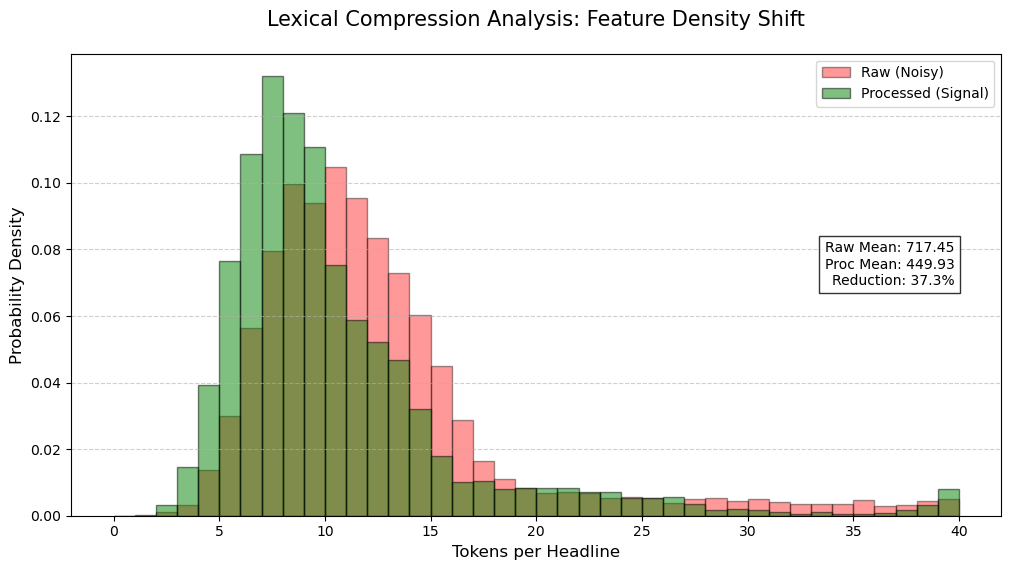

In [29]:
#Character & Token Length Distribution
def plot_length_distribution_final(df, raw_col, proc_col):
    #Calculating lengths and handling any non-string data
    raw_len = df[raw_col].fillna('').astype(str).apply(lambda x: len(x.split()))
    proc_len = df[proc_col].fillna('').astype(str).apply(lambda x: len(x.split()))

    #Figure Setup
    plt.figure(figsize=(12, 6))
    
    #Defining consistent bins
    bins = np.linspace(0, 40, 41) 

    #Plotting Histograms
    plt.hist(raw_len, bins=bins, alpha=0.4, color='red', label='Raw (Noisy)', density=True, edgecolor='black')
    plt.hist(proc_len, bins=bins, alpha=0.5, color='green', label='Processed (Signal)', density=True, edgecolor='black')

    #Titles and Labels
    plt.title("Lexical Compression Analysis: Feature Density Shift", fontsize=15, pad=20)
    plt.xlabel("Tokens per Headline", fontsize=12)
    plt.ylabel("Probability Density", fontsize=12)
    plt.legend(loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

    #Statistical Summary Box
    stats_text = (f"Raw Mean: {raw_len.mean():.2f}\n"
                  f"Proc Mean: {proc_len.mean():.2f}\n"
                  f"Reduction: {((raw_len.mean() - proc_len.mean())/raw_len.mean())*100:.1f}%")
    
    plt.gca().text(0.95, 0.5, stats_text, transform=plt.gca().transAxes, 
                   bbox=dict(facecolor='white', alpha=0.8), horizontalalignment='right')

    plt.savefig('TokenLengthDistribution.png', dpi=300)
    plt.show()

plot_length_distribution_final(dataset_A, 'Article', 'P_Article')

The distribution of document lengths above exhibits a significant leftward shift following preprocessing. The overlap (indicated in gray) marks the preservation of core financial terminology, while the residual raw distribution (pink) highlights the successful removal of linguistic noise. The processed distribution (Green) exhibits a much higher taller peaks compared to the raw distribution (Pink). This indicates that the cleaning pipeline effectively standardized document lengths, reducing the impact of document-length bias and ensuring that the subsequent models are trained on a more consistent and concentrated feature space.

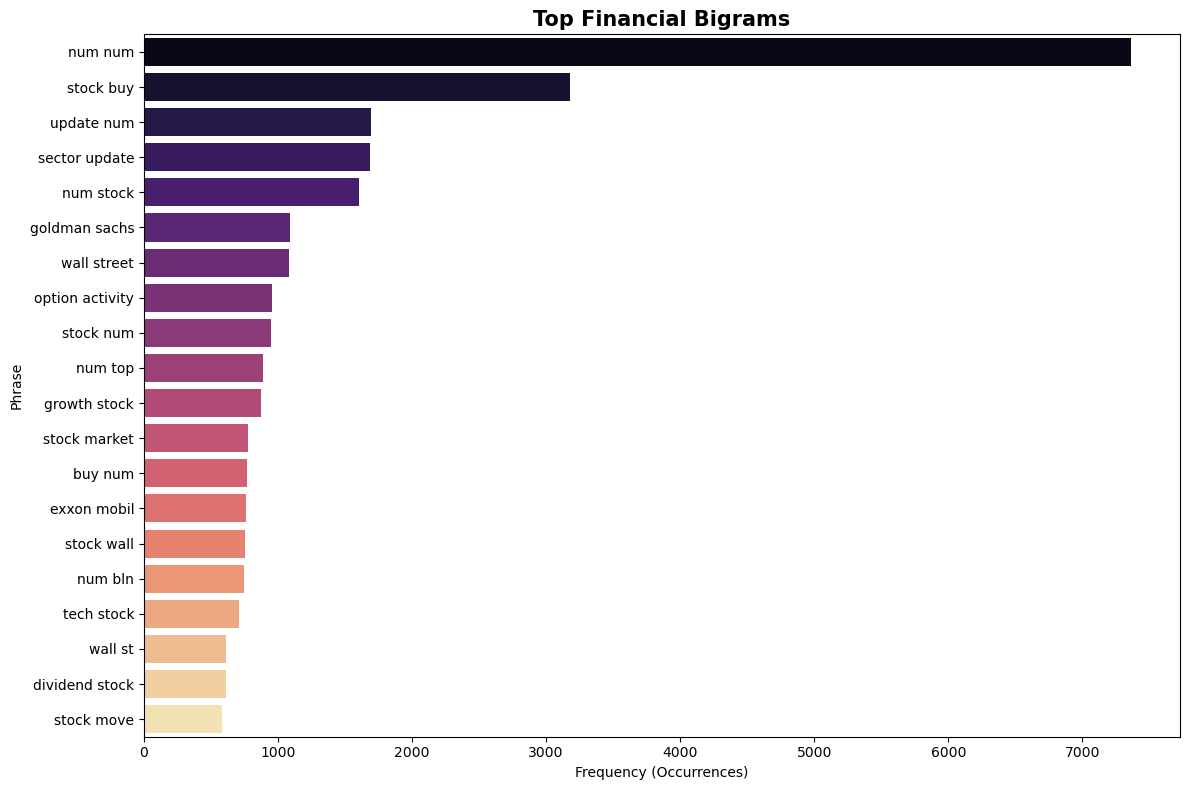

In [30]:
#Top Financial Words & Bigrams (Phrase Extraction)
def plot_top_bigrams_final(df, column, title="Top Financial Bigrams"):
    #Flattenning the text and dropping NaNs
    text_data = df[column].dropna().astype(str)
    all_tokens = " ".join(text_data).split()
    
    #Finder class
    finder = BigramCollocationFinder.from_words(all_tokens)
    
    #Getting the top 20 by frequency
    #ngram_fd is the Frequency Distribution dictionary
    top_20_raw = finder.ngram_fd.most_common(20)
    
    #Formatting for DataFrame
    formatted_data = [
        {"Phrase": f"{bg[0]} {bg[1]}", "Count": count} 
        for bg, count in top_20_raw
    ]
    
    bg_df = pd.DataFrame(formatted_data)
    
    #Plotting
    plt.figure(figsize=(12, 8))
    sns.barplot(data=bg_df, x='Count', y='Phrase', palette='magma')
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel("Frequency (Occurrences)")
    plt.ylabel("Phrase")
    plt.tight_layout()
    plt.show()

plot_top_bigrams_final(dataset_A, 'P_Article_title')

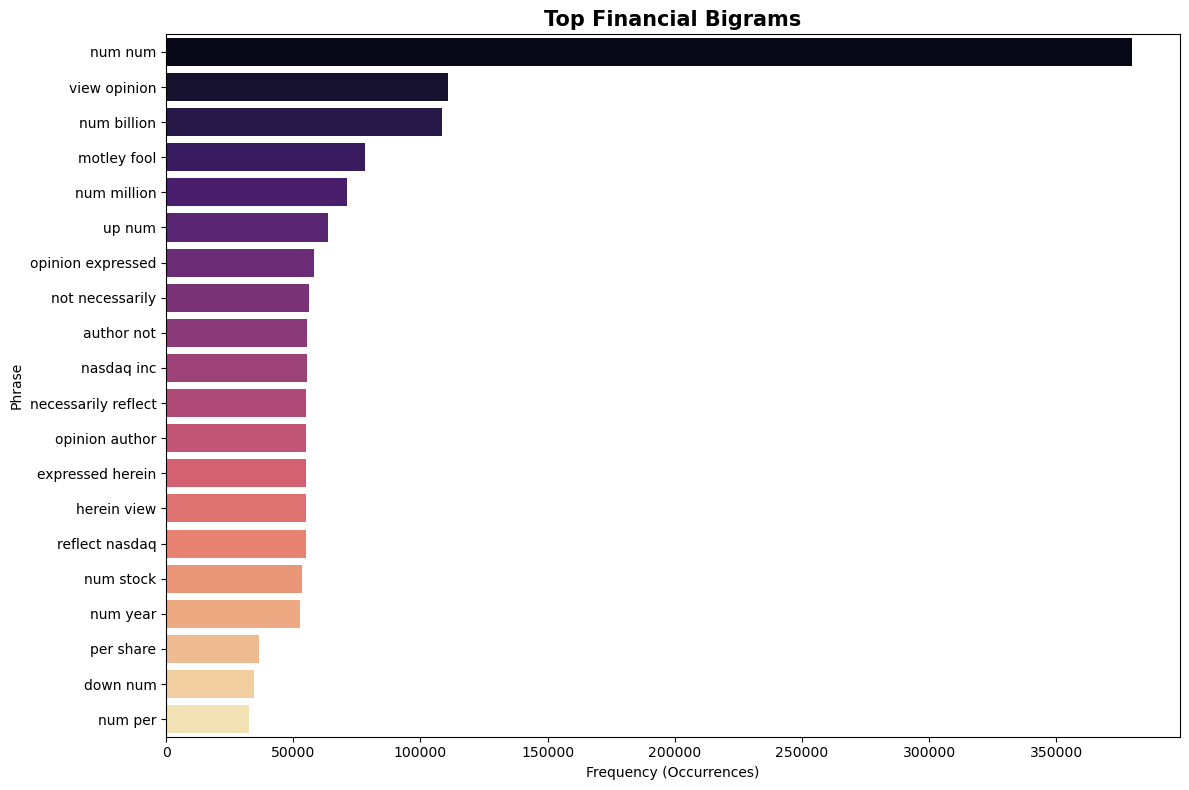

In [31]:
#Top Financial Words & Bigrams (Phrase Extraction)
def plot_top_bigrams_final(df, column, title="Top Financial Bigrams"):
    #Flattenning the text and dropping NaNs
    text_data = df[column].dropna().astype(str)
    all_tokens = " ".join(text_data).split()
    
    #Finder class
    finder = BigramCollocationFinder.from_words(all_tokens)
    
    #Getting the top 20 by frequency
    #ngram_fd is the Frequency Distribution dictionary
    top_20_raw = finder.ngram_fd.most_common(20)
    
    #Formatting for DataFrame
    formatted_data = [
        {"Phrase": f"{bg[0]} {bg[1]}", "Count": count} 
        for bg, count in top_20_raw
    ]
    
    bg_df = pd.DataFrame(formatted_data)
    
    #Plotting
    plt.figure(figsize=(12, 8))
    sns.barplot(data=bg_df, x='Count', y='Phrase', palette='magma')
    
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel("Frequency (Occurrences)")
    plt.ylabel("Phrase")
    plt.tight_layout()
    plt.show()

plot_top_bigrams_final(dataset_A, 'P_Article')